In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Water_Single_Family_Consumption_20250302.csv")

df.head()

,date,monthn,month,Metered households,Unmetered households,Metered consumption,Unmetered consumption,Consumption per capita,Daily consumption per capita
0,September 2016,9,Sep,338517,8427,5609547000,209465045.6,6413.82,213.79
1,November 2016,11,Nov,339436,8303,5160331000,189341562.0,5896.51,196.55
2,October 2016,10,Oct,338925,8369,5725321000,212061126.1,6544.29,211.11
3,July 2016,7,Jul,337911,8573,7209352000,274358224.6,8248.69,266.09
4,December 2016,12,Dec,339642,8256,4987095000,181839067.3,5697.30,183.78


In [3]:
df['date'] = pd.to_datetime(df['date'], format="%B %Y")

df.head()

,date,monthn,month,Metered households,Unmetered households,Metered consumption,Unmetered consumption,Consumption per capita,Daily consumption per capita
0,2016-09-01,9,Sep,338517,8427,5609547000,209465045.6,6413.82,213.79
1,2016-11-01,11,Nov,339436,8303,5160331000,189341562.0,5896.51,196.55
2,2016-10-01,10,Oct,338925,8369,5725321000,212061126.1,6544.29,211.11
3,2016-07-01,7,Jul,337911,8573,7209352000,274358224.6,8248.69,266.09
4,2016-12-01,12,Dec,339642,8256,4987095000,181839067.3,5697.30,183.78


In [4]:
df = df.sort_values(by='date')
df = df.drop(columns=["Metered households", "Unmetered households", 
                      "Metered consumption", "Unmetered consumption", 
                      "Consumption per capita"])
df.head()

,date,monthn,month,Daily consumption per capita
37,2010-01-01,1,Jan,239.30
52,2010-02-01,2,Feb,245.89
80,2010-03-01,3,Mar,208.68
36,2010-04-01,4,Apr,222.36
29,2010-05-01,5,May,241.23


In [10]:
df['year'] = df['date'].dt.year
df.shape

KeyError: 'date'

In [22]:
generated_data = pd.read_csv("generated_water_usage.csv")
generated_data.head()

,Normalized Water Usage
0,0.200000
1,0.206656
2,0.202852
3,0.202852
4,0.228207


In [11]:
import numpy as np
import pandas as pd
from calendar import monthrange
import datetime
df = pd.read_csv("./ml_workflows/water_consumption_forecast.csv")

In [18]:
df.head()
df['timestamp'] = pd.to_datetime(df['timestamp'], format="%Y-%m-%d")
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

In [23]:

expanded_data = []

for _, row in df.iterrows():
    year = row['year']
    month  = row['month']
    daily_avg = row['water_consumption']
    
    # Get month info
    days_in_month = monthrange(year, month)[1]
    total_hours = days_in_month * 24
    
    first_day_weekday = datetime.date(year, month, 1).weekday()  # Returns 0 (Monday) to 6 (Sunday)
    shift_hours = first_day_weekday * 24  # Number of hours to shift the pattern
    
    normalized_pattern = generated_data['Normalized Water Usage'].values
    shifted_pattern = np.roll(normalized_pattern, shift=-shift_hours)
    
    S = np.sum(normalized_pattern)
    scaling_factor = (daily_avg * 7) / S  # Ensures weekly average matches daily_avg
    
    num_repeats = (total_hours + len(shifted_pattern) - 1) // len(shifted_pattern)
    scaled_values = np.tile(shifted_pattern, num_repeats)[:total_hours] * scaling_factor
    
    date_range = pd.date_range(start=f"{year}-{month:02d}-01", periods=total_hours, freq='H')
    
    expanded_data.extend(zip(date_range, scaled_values))

final_df = pd.DataFrame(expanded_data, columns=['timestamp', 'water_usage'])

/tmp/ipykernel_764178/4166349588.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start=f"{year}-{month:02d}-01", periods=total_hours, freq='H')


In [24]:
final_df.head()

final_df.to_csv("expanded_water_usage.csv", index=False)

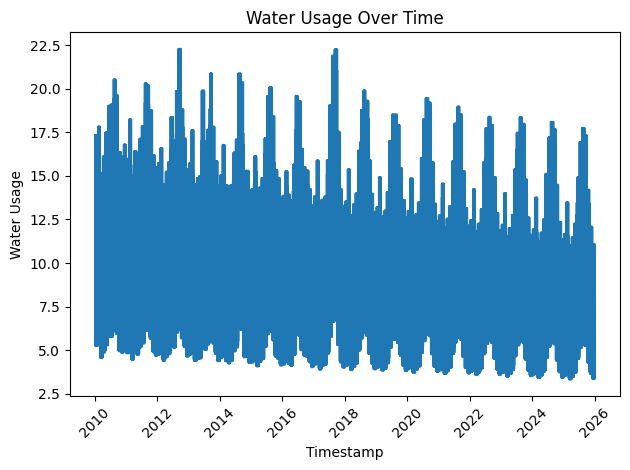

In [25]:
plt.plot(final_df['timestamp'], final_df['water_usage'])
plt.xlabel('Timestamp')
plt.ylabel('Water Usage')
plt.title('Water Usage Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("water_usage_plot.png")
# Display the plot
plt.show()

Text(0, 0.5, 'Water Usage')

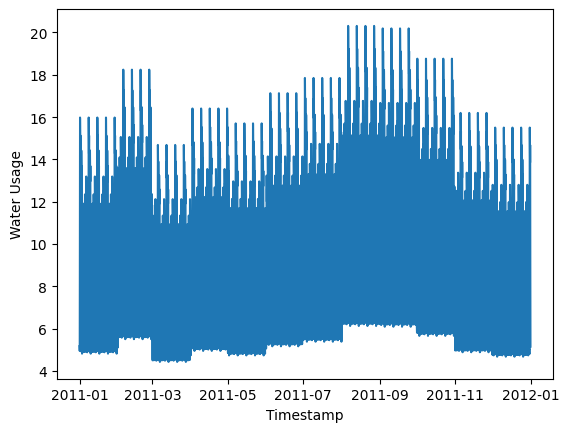

In [27]:
sample_data = final_df[(final_df['timestamp'].dt.year == 2011)]
plt.plot(sample_data['timestamp'], sample_data['water_usage'])
plt.xlabel('Timestamp')
plt.ylabel('Water Usage')


In [45]:
df.to_csv("calgary_water_analysis.csv")

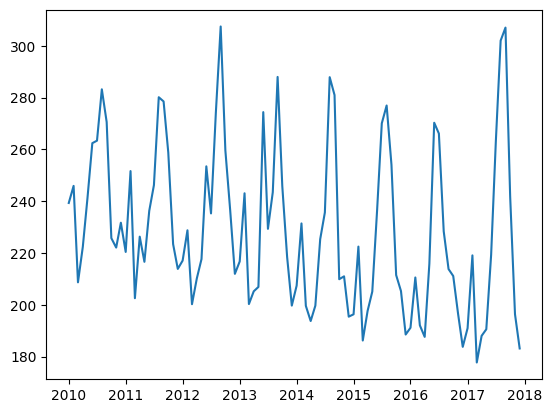

In [56]:
plt.plot(df['date'], df['Daily consumption per capita'])

In [58]:
df_monthly_avg = df.groupby('monthn').mean(numeric_only=True)
print(df_monthly_avg)

# df_monthly_avg_specific = df_monthly_avg[(df_monthly_avg['month'] == 'Jan')]

# print(df_monthly_avg_specific)

        Daily consumption per capita
monthn                              
1                          209.92125
2                          231.60125
3                          195.92875
4                          203.89375
5                          211.70250
6                          247.24750
7                          251.09625
8                          271.98875
9                          275.01125
10                         233.02250
11                         213.69875
12                         201.01500


In [48]:
# Group by year and compute the mean for all numerical columns
df_yearly_avg = df.groupby(df['date'].dt.year).mean(numeric_only=True)
print(df_yearly_avg)


      monthn  Daily consumption per capita
date                                      
2010     6.5                    243.032500
2011     6.5                    237.880833
2012     6.5                    237.676667
2013     6.5                    230.933333
2014     6.5                    223.157500
2015     6.5                    220.895833
2016     6.5                    213.936667
2017     6.5                    223.238333
